## 环境准备

In [ ]:
import sys

sys.path.append("..")

In [ ]:
import json
import time
from collections import Counter
from pathlib import Path
from typing import Literal

import jieba
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

## 超参数

### 路径

In [ ]:
ROOT = Path.cwd().parent


def get_dir(dir: Path) -> Path:
    if not dir.exists():
        dir.mkdir(parents=True)
    return dir


DATASETS_DIR = get_dir(ROOT / "datasets")
OUTPUTS_DIR = get_dir(ROOT / "outputs")

RAW_DATASETS_DIR = get_dir(DATASETS_DIR / "raw")
PROCESSED_DATASETS_DIR = get_dir(DATASETS_DIR / "processed")

MODELS_DIR = get_dir(OUTPUTS_DIR / "models")
LOGS_DIR = get_dir(OUTPUTS_DIR / "logs")
CHECKPOINTS_DIR = get_dir(OUTPUTS_DIR / "checkpoints")
FIGURES_DIR = get_dir(OUTPUTS_DIR / "figures")

STOPWORDS_PATH = DATASETS_DIR / "stopwords.txt"
RAW_DATASETS_PATH = RAW_DATASETS_DIR / "online_shopping_10_cats.csv"
PROCESSED_DATASETS_PATH = PROCESSED_DATASETS_DIR / "processed_datasets.csv"

BEST_MODEL_PATH = MODELS_DIR / "best_model.pth"
LAST_MODEL_PATH = MODELS_DIR / "last_model.pth"

### 通用设置

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

### 数据

In [ ]:
# 最长序列长度
MAX_SEQ_LENGTH = 128

# 最小频率
MIN_FREQ = 3

# 是否移除停用词
REMOVE_STOPWORDS = True

# 训练集, 验证集, 测试集的比例
TRAIN_RATIO = 0.7
VALID_RATIO = 0.2
TEST_RATIO = 0.1

### 模型

In [ ]:
# 模型类型
MODEL_TYPE: Literal["LSTM", "RNN", "GRU"] = "LSTM"

# 嵌入维度
EMBEDDING_DIM = 300

# 隐藏层维度
HIDDEN_DIM = 256

# 层数数量
NUM_LAYERS = 2

# Dropout率
DROPOUT = 0.5

# 是否使用双向RNN
BIDIRECTIONAL = True

# 使用Attention机制
USE_ATTENTION = True

### 训练

In [ ]:
# Batch大小
BATCH_SIZE = 64

# 学习率
LEARNING_RATE = 1e-2

# 权重衰减
WEIGHT_DECAY = 1e-5

# 训练轮数
EPOCHS = 50

# 梯度裁剪
GRAD_CLIP = 1.0

# 学习率调整参数
# 当验证集性能不再提升时，学习率乘以LR_REDUCE_FACTOR
LR_REDUCE_FACTOR = 0.5
# 当验证集性能不再提升时，等待LR_REDUCE_PATIENCE轮后才调整学习率
LR_REDUCE_PATIENCE = 3

# 早停参数
# 当验证集性能不再提升时，等待EARLY_STOP_PATIENCE轮后停止训练
EARLY_STOP_PATIENCE = 5
# 当验证集性能提升小于EARLY_STOP_MIN_DELTA时，认为性能不再提升
EARLY_STOP_MIN_DELTA = 1e-4

## 数据处理

### 词表映射

In [ ]:
class VocabMapping:
    def __init__(self, word2idx: dict[str, int], idx2word: dict[int, str]):
        self.word2idx = word2idx
        self.idx2word = idx2word

    @property
    def vocab_size(self) -> int:
        return len(self.word2idx)

    @property
    def pad_idx(self) -> int:
        return 0

    @property
    def unk_idx(self) -> int:
        return 1

    def to_dict(self) -> dict[str, dict]:
        return {
            "word2idx": self.word2idx,
            "idx2word": {str(k): v for k, v in self.idx2word.items()},
        }

    @classmethod
    def from_dict(cls, data: dict[str, dict]) -> "VocabMapping":
        word2idx = data["word2idx"]
        idx2word = {int(k): v for k, v in data["idx2word"].items()}
        return cls(word2idx, idx2word)

    def save(self, path: Path) -> None:
        with path.open("w", encoding="utf-8") as f:
            json.dump(self.to_dict(), f, ensure_ascii=False, indent=4)

    @classmethod
    def load(cls, path: Path) -> "VocabMapping":
        with path.open("r", encoding="utf-8") as f:
            data = json.load(f)
            return cls.from_dict(data)

### 数据预处理

In [ ]:
df = pd.read_csv(RAW_DATASETS_PATH)
df

,Unnamed: 0,cat,label,text
0,0,书籍,1,﻿做父母一定要有刘墉这样的心态，不断地学习，不断地进步，不断地给自己补充新鲜血液，让自己保持...
1,1,书籍,1,作者真有英国人严谨的风格，提出观点、进行论述论证，尽管本人对物理学了解不深，但是仍然能感受到...
2,2,书籍,1,作者长篇大论借用详细报告数据处理工作和计算结果支持其新观点。为什么荷兰曾经县有欧洲最高的生产...
3,3,书籍,1,作者在战几时之前用了＂拥抱＂令人叫绝．日本如果没有战败，就有会有美军的占领，没胡官僚主义的延...
4,4,书籍,1,作者在少年时即喜阅读，能看出他精读了无数经典，因而他有一个庞大的内心世界。他的作品最难能可贵...
...,...,...,...,...
62769,62769,酒店,0,我们去盐城的时候那里的最低气温只有4度，晚上冷得要死，居然还不开空调，投诉到酒店客房部，得到...
62770,62770,酒店,0,房间很小，整体设施老化，和四星的差距很大。毛巾太破旧了。早餐很简陋。房间隔音很差，隔两间房间...
62771,62771,酒店,0,我感觉不行。。。性价比很差。不知道是银川都这样还是怎么的！
62772,62772,酒店,0,房间时间长，进去有点异味！服务员是不是不够用啊！我在一楼找了半个小时以上才找到自己房间，想找...


In [ ]:
def read_raw(filepath: Path = RAW_DATASETS_PATH) -> tuple[list[str], list[int]]:
    """
    读取原始数据集文件，返回一个包含文本和标签的列表。
    Args:
        filepath (Path): 原始数据集文件的路径
    Returns:
        texts (list[str]): 文本列表
        labels (list[int]): 标签列表
    """
    if filepath.suffix == ".csv":
        df = pd.read_csv(filepath)
    elif filepath.suffix == ".json":
        df = pd.read_json(filepath)
    else:
        raise ValueError(f"不支持的文件格式: {str(filepath)}")

    texts = [
        str(t).strip() for t in df["text"].tolist() if pd.notna(t) and str(t).strip()
    ]
    labels = [
        l
        for i, l in enumerate(df["label"].tolist())  # noqa: E741
        if pd.notna(df["text"].iloc[i]) and str(df["text"].iloc[i]).strip()
    ]

    # 过滤空文本和非法标签
    valid = [(t, l) for t, l in zip(texts, labels) if t and (l in (0, 1))]  # noqa: E741
    texts = [v[0] for v in valid]
    labels = [v[1] for v in valid]

    print(f"读取数据: {len(texts)}条")
    print(f"正样本: {sum(labels)}, 负样本: {len(labels) - sum(labels)}")

    return texts, labels

### 分词

In [ ]:
def tokenize(
    texts: list[str], remove_stopwords: bool = REMOVE_STOPWORDS
) -> list[list[str]]:
    """
    jieba 分词, 去掉停用词
    Args:
        texts(list[str]): 文本列表
        remove_stopwords(bool): 是否移除停用词
    Returns:
        result: 分词结果

    """
    stopwords = set()
    stopwords_path = STOPWORDS_PATH
    if remove_stopwords and stopwords_path.exists():
        with stopwords_path.open(mode="r", encoding="utf-8") as f:
            stopwords = set(line.strip for line in f if line.strip())

    result = []
    for text in texts:
        words = jieba.lcut(text)
        words = [w.strip() for w in words if w.strip()]
        if remove_stopwords:
            words = [w for w in words if w not in stopwords]
        if words:
            result.append(words)

    print(f"分词成功: {len(result)}")
    print(f"平均长度为: {np.mean([len(r) for r in result])}")
    return result

### 构建词表

In [ ]:
def build_vocab(
    tokenized_texts: list[list[str]], min_freq: int = MIN_FREQ
) -> VocabMapping:
    """
    构建词表
    Args:
        tokenized_texts(list[str]): 分词后的文本列表
        min_freq(int): 词出现的最小频率
    Returns:
        VocabMapping(word2idx, idx2word): 分词表
    """
    counter = Counter()
    for tokens in tokenized_texts:
        counter.update(tokens)

    word2idx = {"<PAD>": 0, "<UNK>": 1}
    idx2word = {0: "<PAD>", 1: "<UNK>"}

    idx = 2
    for word, freq in counter.most_common():
        if freq >= min_freq:
            word2idx[word] = idx
            idx2word[idx] = word
            idx += 1

    print(f"词表大小: {len(word2idx)} (min_freq = {min_freq})")
    return VocabMapping(word2idx, idx2word)

### 文本 -> 索引序列

In [ ]:
def encode(
    tokenized_texts: list[list[str]], word2idx: dict[str, int]
) -> list[list[str]]:
    """
    文本变成索引序列
    Args:
        tokenized_texts(list[list[str]]): 被分词后的文本
        word2idx(dict[str, int]): 词表索引
    Returns:
        sequences(list[list[str]]): 索引列表
    """
    sequences = []
    for tokens in tokenized_texts:
        seq = [word2idx.get(w, 1) for w in tokens]
        sequences.append(seq)

    return sequences

### 填充和截断

In [ ]:
def pad_or_truncate(
    sequences: list[list[str]], max_seq_len: int = MAX_SEQ_LENGTH
) -> torch.Tensor:
    """
    填充和截断一整个sequences
    Args:
        sequences(list[list[str]]): 索引列表
        max_seq_len(int): 截断长度
    """
    padded = []
    for seq in sequences:
        if len(seq) > max_seq_len:
            padded.append(seq[:max_seq_len])
        else:
            padded.append(seq + [0] * (max_seq_len - len(seq)))
    return torch.tensor(padded, dtype=torch.long)

### 生成Attension Mask

In [ ]:
def create_mask(padded: torch.Tensor) -> torch.Tensor:
    """
    生成Attention Mask
    Args:
        padded(torch.Tensor): 被处理过的文本序列
    Returns:
        Tensor: Attention 掩码
    """
    return (padded != 0).long()

### 划分数据集

In [ ]:
def split_data(
    input_idxs: list[int], masks: list[torch.Tensor], labels: list[int]
) -> tuple[
    tuple[torch.Tensor, torch.Tensor, torch.Tensor],
    tuple[torch.Tensor, torch.Tensor, torch.Tensor],
    tuple[torch.Tensor, torch.Tensor, torch.Tensor],
]:
    """
    划分 train/val/test
    Args:
        input_idxs: 输入的文本索引
        masks: Attention Mask
        labels: 标签
    Returns:
        ((train_idxs, train_masks, train_labels),
        (val_idxs, val_masks, val_labels),
        (test_idxs, test_masks, test_labels))
    """
    labels_tensor = torch.tensor(labels, dtype=torch.float32)

    temp_ratio = VALID_RATIO + TEST_RATIO

    # stratify 参数确保了训练集、验证集和测试集中正负样本的比例与原始数据集相同
    train_idxs, temp_idxs, train_masks, temp_masks, train_labels, temp_labels = (
        train_test_split(
            input_idxs,
            masks,
            labels_tensor,
            test_size=temp_ratio,
            stratify=labels_tensor.numpy(),
            random_state=42,
        )
    )

    # 计算验证集在临时数据中的比例
    val_ratio_in_temp = VALID_RATIO / temp_ratio
    val_idxs, test_idxs, val_masks, test_masks, val_labels, test_labels = (
        train_test_split(
            temp_idxs,
            temp_masks,
            temp_labels,
            test_size=1 - val_ratio_in_temp,
            stratify=temp_labels.numpy(),
            random_state=42,
        )
    )

    print(f"划分: train={len(train_idxs)}, val={len(val_idxs)}, test={len(test_idxs)}")
    return (
        (train_idxs, train_masks, train_labels),
        (val_idxs, val_masks, val_labels),
        (test_idxs, test_masks, test_labels),
    )

### 定义数据集类

In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, input_idxs, masks, labels):
        self.input_idxs = input_idxs
        self.masks = masks
        self.labels = labels.float().unsqueeze(1)

    def __getitem__(self, idx):
        return self.input_idxs[idx], self.masks[idx], self.labels[idx]

    def __len__(self):
        return len(self.labels)

### 获取DataLoader

In [ ]:
def create_data_loaders(
    train_data, val_data, test_data, batch_size=BATCH_SIZE, num_workers=0
):
    """创建 DataLoader"""
    train_ds = SentimentDataset(*train_data)
    val_ds = SentimentDataset(*val_data)
    test_ds = SentimentDataset(*test_data)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers
    )

    return train_loader, val_loader, test_loader

### 使用真实数据

In [ ]:
texts, labels = read_raw(RAW_DATASETS_PATH)
tokenized_texts = tokenize(texts, remove_stopwords=REMOVE_STOPWORDS)
vocab = build_vocab(tokenized_texts, min_freq=MIN_FREQ)
input_idxs = encode(tokenized_texts, vocab.word2idx)
padded = pad_or_truncate(input_idxs, max_seq_len=MAX_SEQ_LENGTH)
masks = create_mask(padded)
train_data, val_data, test_data = split_data(padded, masks, labels)
train_loader, val_loader, test_loader = create_data_loaders(
    train_data, val_data, test_data
)

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\NayeyYe\AppData\Local\Temp\jieba.cache


读取数据: 62773条
正样本: 31727, 负样本: 31046


Loading model cost 0.379 seconds.
Prefix dict has been built successfully.


分词成功: 62773
平均长度为: 37.10753030761633
词表大小: 24923 (min_freq = 3)
划分: train=43941, val=12554, test=6278


## 模型定义

### Bahdanau 加性注意力

In [ ]:
class Attention(nn.Module):
    """
    Bahdanau Attention 机制实现

    """

    def __init__(self, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1, bias=False),
        )

    def forward(self, rnn_out, mask) -> torch.Tensor:
        """
        Args:
            rnn_out: RNN输出, 形状为 (batch_size, seq_len, hidden_dim)
            mask: Attention Mask, 形状为 (batch_size, seq_len)
        Returns:
            context: 上下文向量, 形状为 (batch_size, hidden_dim)
        """
        scores = self.score(rnn_out).squeeze(-1)  # (batch_size, seq_len)
        scores = scores.masked_fill(mask == 0, -1e9)  # 将padding位置的分数设为很小的值
        attn_weights = F.softmax(scores, dim=1)  # (batch_size, seq_len)
        context = torch.bmm(attn_weights.unsqueeze(1), rnn_out).squeeze(
            1
        )  # (batch_size, hidden_dim)
        return context

### BaseRNN 基类

In [ ]:
class BaseRNN(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        pad_idx: int,
        embedding_dim: int = EMBEDDING_DIM,
        hidden_dim: int = HIDDEN_DIM,
        num_layers: int = NUM_LAYERS,
        dropout: float = DROPOUT,
        bidirectional: bool = BIDIRECTIONAL,
        use_attention: bool = USE_ATTENTION,
        rnn_type: Literal["LSTM", "RNN", "GRU"] = MODEL_TYPE,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(dropout)
        self.use_attention = use_attention
        self.bidirectional = bidirectional
        self.rnn_type = rnn_type

        rnn_dropout = dropout if num_layers > 1 else 0.0
        rnn_cls = {
            "LSTM": nn.LSTM,
            "RNN": nn.RNN,
            "GRU": nn.GRU,
        }[rnn_type]
        self.rnn = rnn_cls(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=rnn_dropout,
            bidirectional=bidirectional,
            batch_first=True,
        )

        self.hidden_size = hidden_dim * 2 if bidirectional else hidden_dim
        if use_attention:
            self.attention = Attention(self.hidden_size)
        self.fc = nn.Linear(self.hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, input_idxs, mask):
        embedded = self.dropout(
            self.embedding(input_idxs)
        )  # (batch_size, seq_len, embedding_dim)
        rnn_out, _ = self.rnn(
            embedded
        )  # (batch_size, seq_len, hidden_dim * num_directions)

        if self.use_attention:
            context = self.attention(
                rnn_out, mask
            )  # (batch_size, hidden_dim * num_directions)
        else:
            if self.bidirectional:
                context = torch.cat(
                    (
                        rnn_out[:, -1, : self.hidden_size // 2],
                        rnn_out[:, 0, self.hidden_size // 2 :],
                    ),
                    dim=1,
                )
            else:
                context = rnn_out[:, -1, :]

        output = self.fc(context)
        output = self.sigmoid(output)
        return output

### 创建模型

In [ ]:
def build_model(vocab_size, pad_idx):
    return BaseRNN(
        vocab_size=vocab_size,
        pad_idx=pad_idx,
        embedding_dim=EMBEDDING_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        bidirectional=BIDIRECTIONAL,
        use_attention=USE_ATTENTION,
        rnn_type=MODEL_TYPE,
    )

In [ ]:
model = build_model(vocab.vocab_size, vocab.pad_idx).to(DEVICE)
total, trainable = (
    sum(p.numel() for p in model.parameters()),
    sum(p.numel() for p in model.parameters() if p.requires_grad),
)
print(
    f"模型: {MODEL_TYPE.upper()} + {'Attention' if USE_ATTENTION else 'LastStep'}, 双向={BIDIRECTIONAL}"
)
print(f"参数: total={total:,}, trainable={trainable:,}")
model

模型: LSTM + Attention, 双向=True
参数: total=10,328,741, trainable=10,328,741


BaseRNN(
  (embedding): Embedding(24923, 300, padding_idx=0)
  (dropout): Dropout(p=0.5, inplace=False)
  (rnn): LSTM(300, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (attention): Attention(
    (score): Sequential(
      (0): Linear(in_features=512, out_features=256, bias=True)
      (1): Tanh()
      (2): Linear(in_features=256, out_features=1, bias=False)
    )
  )
  (fc): Linear(in_features=512, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

## 训练组件

### 早停

In [ ]:
class EarlyStopping:
    def __init__(
        self,
        patience: int = EARLY_STOP_PATIENCE,
        min_delta: float = EARLY_STOP_MIN_DELTA,
    ):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.should_stop = False

    def __call__(self, val_loss):
        if self.best_score is None:
            self.best_score = val_loss
        elif val_loss > self.best_score - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        else:
            self.best_score = val_loss
            self.counter = 0
        return self.should_stop

    def state_dict(self):
        return {
            "counter": self.counter,
            "best_score": self.best_score,
            "should_stop": self.should_stop,
        }

    def load_state_dict(self, state):
        self.counter = state["counter"]
        self.best_score = state["best_score"]
        self.should_stop = state["should_stop"]

### 保存和加载checkpoint

In [ ]:
def save_checkpoint(
    path: Path,
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler._LRScheduler,
    epoch: int,
    val_loss: float,
    vocab: VocabMapping,
):
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "val_loss": val_loss,
            "vocab": vocab.to_dict(),
        },
        path,
    )

In [ ]:
def load_checkpoint(
    path: Path,
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer = None,
    scheduler: torch.optim.lr_scheduler._LRScheduler = None,
):
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    if optimizer:
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    if scheduler:
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    return ckpt

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=LR_REDUCE_FACTOR, patience=LR_REDUCE_PATIENCE
)
criterion = nn.BCELoss()
early_stopping = EarlyStopping(EARLY_STOP_PATIENCE, EARLY_STOP_MIN_DELTA)

## 训练

### 一个Epoch

#### 训练

In [ ]:
def train_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    epoch: int,
) -> tuple[float, float]:
    """训练一个epoch
    Args:
        model(nn.Module): 模型
        dataloader(DataLoader): 训练数据加载器
        optimizer(torch.optim.Optimizer): 优化器
        criterion(nn.Module): 损失函数
        epoch(int): 当前epoch数

    Returns:
        total_loss(float): 平均损失
        total_acc(float): 平均准确率
    """
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0
    pbar = tqdm(dataloader, desc=f"[Train] Epoch {epoch + 1}/{EPOCHS}", unit="batch")

    for input_idxs, masks, labels in pbar:
        input_idxs, masks, labels = (
            input_idxs.to(DEVICE),
            masks.to(DEVICE),
            labels.to(DEVICE),
        )

        optimizer.zero_grad()
        outputs = model(input_idxs, masks)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        total_loss += loss.item() * input_idxs.size(0)
        preds = (outputs >= 0.5).float()
        total_correct += (preds == labels).sum().item()
        total_samples += input_idxs.size(0)

        pbar.set_postfix(
            {
                "loss": f"{total_loss / total_samples:.4f}",
                "acc": f"{total_correct / total_samples:.4f}",
            }
        )
    return total_loss / total_samples, total_correct / total_samples

#### 评测

In [ ]:
@torch.no_grad()
def val_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    epoch: int,
    mode: Literal["Val", "Test"] = "Val",
) -> tuple[float, float]:
    """评估模型
    Args:
        model(nn.Module): 模型
        dataloader(DataLoader): 数据加载器
        criterion(nn.Module): 损失函数
        epoch(int): 当前epoch数
        mode(Literal["Val", "Test"]): 评估模式, "Val"或"Test"

    Returns:
        total_loss(float): 平均损失
        total_acc(float): 平均准确率
    """
    model.eval()
    total_loss, total_correct, total_samples = 0, 0, 0
    pbar = tqdm(dataloader, desc=f"[{mode}] Epoch {epoch + 1}/{EPOCHS}", unit="batch")

    for input_idxs, masks, labels in pbar:
        input_idxs, masks, labels = (
            input_idxs.to(DEVICE),
            masks.to(DEVICE),
            labels.to(DEVICE),
        )

        outputs = model(input_idxs, masks)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * input_idxs.size(0)
        preds = (outputs >= 0.5).float()
        total_correct += (preds == labels).sum().item()
        total_samples += input_idxs.size(0)

        pbar.set_postfix(
            {
                "loss": f"{total_loss / total_samples:.4f}",
                "acc": f"{total_correct / total_samples:.4f}",
            }
        )
    return total_loss / total_samples, total_correct / total_samples

### 完整流程

In [ ]:
best_val_loss = float("inf")
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}
print(
    f"开始训练: {MODEL_TYPE.upper()}, epochs={EPOCHS}, lr={LEARNING_RATE}, batch_size={BATCH_SIZE}"
)
start_time = time.time()
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, epoch
    )
    val_loss, val_acc = val_one_epoch(model, val_loader, criterion, epoch)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_checkpoint(
            BEST_MODEL_PATH,
            model,
            optimizer,
            scheduler,
            epoch,
            val_loss,
            vocab,
        )

    save_checkpoint(
        LAST_MODEL_PATH,
        model,
        optimizer,
        scheduler,
        epoch,
        val_loss,
        vocab,
    )

    if early_stopping(val_loss):
        print(f"早停触发: 验证集损失在 {EARLY_STOP_PATIENCE} 轮内没有显著提升")
        break

total_time = time.time() - start_time
print(f"训练完成, 总耗时: {total_time:.2f}秒, 最佳验证损失: {best_val_loss:.4f}")

开始训练: LSTM, epochs=50, lr=0.01, batch_size=64


[Val] Epoch 6/50: 100%|██████████| 197/197 [00:02<00:00, 72.41batch/s, loss=0.2383, acc=0.9088]


早停触发: 验证集损失在 5 轮内没有显著提升
训练完成, 总耗时: 191.10秒, 最佳验证损失: 0.2040


## 可视化

### 训练曲线

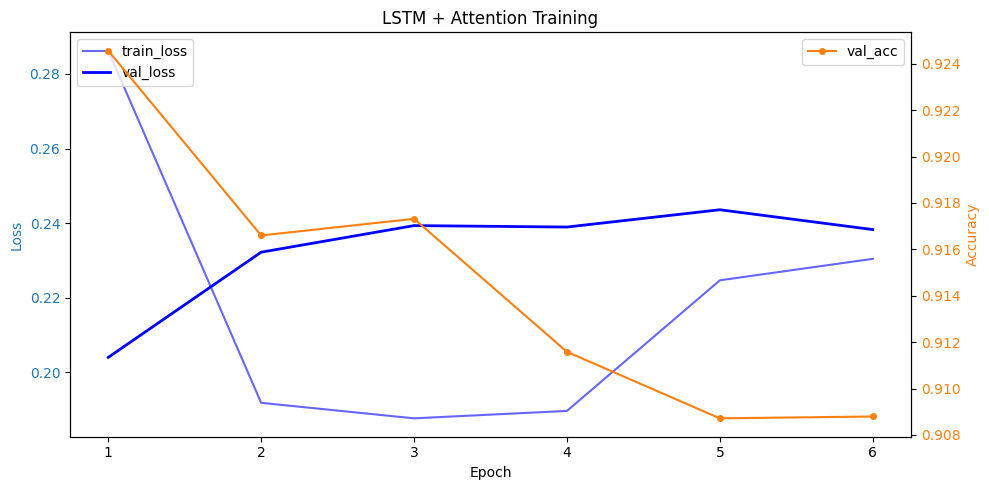

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))
epochs_range = range(1, len(history["train_loss"]) + 1)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss", color="tab:blue")
ax1.plot(epochs_range, history["train_loss"], "b-", label="train_loss", alpha=0.6)
ax1.plot(epochs_range, history["val_loss"], "b-", label="val_loss", linewidth=2)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.set_ylabel("Accuracy", color="tab:orange")
ax2.plot(
    epochs_range,
    history["val_acc"],
    "o-",
    color="tab:orange",
    label="val_acc",
    markersize=4,
)
ax2.tick_params(axis="y", labelcolor="tab:orange")
ax2.legend(loc="upper right")

plt.title(
    f"{MODEL_TYPE.upper()} + {'Attention' if USE_ATTENTION else 'LastStep'} Training"
)
fig.tight_layout()
plt.savefig(FIGURES_DIR / "training_curve.png", dpi=150)
plt.show()

## 测试集评估

### 评估

In [ ]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []

    for input_ids, masks, labels in tqdm(loader, desc="evaluate"):
        input_ids = input_ids.to(DEVICE)
        masks = masks.to(DEVICE)

        logits = model(input_ids, masks)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs > 0.5).astype(int)

        all_preds.extend(preds.flatten())
        all_probs.extend(probs.flatten())
        all_labels.extend(labels.numpy().flatten())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [ ]:
print("📊 评估最佳模型...")
best_ckpt = load_checkpoint(BEST_MODEL_PATH, model)
y_true, y_pred, y_prob = evaluate(model, test_loader)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
auc = roc_auc_score(y_true, y_prob)

print(f"""
{"=" * 40}
  评估结果
{"=" * 40}
  Accuracy:   {accuracy:.4f}
  Precision:  {precision:.4f}
  Recall:     {recall:.4f}
  F1 Score:   {f1:.4f}
  AUC:        {auc:.4f}
{"=" * 40}

{classification_report(y_true, y_pred, target_names=["负面", "正面"], zero_division=0)}
""")

### 混淆矩阵

### ROC 曲线

## 推理